In [ ]:
import marimo as mo
import mne
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
# plt.rcParams.update({"figure.dpi": 300})
import os
import librosa
from cleese_stim.engines import PhaseVocoder
from cleese_stim.engines.phase_vocoder import utils as pvutils
from sklearn.preprocessing import StandardScaler
from mtrf import TRF
from mtrf.stats import neg_mse, pearsonr, nested_crossval
import pandas as pd
import seaborn as sns
import eelbrain as eb
eb.configure(frame=False)
from scipy import stats
from scipy.signal import resample
from tqdm import tqdm
import warnings

# ERP analysis

## Pipeline

### Functions to clean up event markers

In [ ]:
def events_without_python(raw):
    events_from_annot, event_dict = mne.events_from_annotations(raw)

    # Get indices of R11 events with event code 1011 or New Segment indices with event code 99999 and delete them
    useless_events = list(filter(lambda i:
                                 events_from_annot[:, 2][i] == 99999 or 
                                 events_from_annot[:, 2][i] == 1011 or 
                                 events_from_annot[:, 2][i] == 2 or 
                                 events_from_annot[:, 2][i] == 6, 
                                 range(len(events_from_annot[:, 2]))
                                ))
    events = np.delete(events_from_annot, useless_events, 0)

    for i in range(len(events[:, 2])):
        if events[:, 2][i] == 1004 or events[:, 2][i] == 1008:
            events[:, 2][i] = 1001
        elif  events[:, 2][i] == 1012:
            events[:, 2][i] = 1002
        elif events[:, 2][i] == 1024:
            events[:, 2][i] = 1003
        elif events[:, 2][i] == 1028:
            events[:, 2][i] = 1004

    return events

In [ ]:
def events_with_python(raw):
    events_from_annot, event_dict = mne.events_from_annotations(raw)

    # Get indices of R11 events with event code 1011 or New Segment indices with event code 99999 and delete them
    useless_events = list(filter(lambda i: 
                                 events_from_annot[:, 2][i] == 99999 or 
                                 events_from_annot[:, 2][i] == 1011, 
                                 range(len(events_from_annot[:, 2]))
                                ))
    events = np.delete(events_from_annot, useless_events, 0)

    # Get indices of consective equal events and keep only the 1st one and delete the others
    consecutive_equal_events = list(filter(lambda i: events[:, 2][i] == events[:, 2][i+1], range(len(events[:, 2])-1)))
    consecutive_equal_events = [index+1 for index in consecutive_equal_events]
    events = np.delete(events, consecutive_equal_events, 0)

    # If experiment starts with an S event with event code 2, delete it
    if events[:, 2][0] == 2:
        events = np.delete(events, 0, 0)

    # Change S event so it takes event code from R events (for e.g.- if R3 is followed by S2, change it to S3)
    for i in range(0, len(events), 2):
        events[i+1][2] = events[i][2]

    # Extract S events into different array
    s_events = events[1::2]

    return s_events

### Functions to preprocess data

In [ ]:
def create_stim_channel(raw, events):
    raw.load_data()
    stim_data = np.zeros((1, len(raw.times)))

    # Add stimulus channel in 'raw' object's info class
    info = mne.create_info(["STI"], raw.info["sfreq"], ["stim"])
    stim_raw = mne.io.RawArray(stim_data, info)
    raw.add_channels([stim_raw], force_update_info=True)

    # Add events extracted from annotations to the stimulus channel
    raw.add_events(events, stim_channel="STI")

In [ ]:
def crop_data(raw, t_from, t_to):
    first_event_time = mne.find_events(raw)[0][0]
    last_event_time = mne.find_events(raw)[-1][0]

    part_to_remove_from_beginning = (first_event_time - abs(t_from*500))/1000
    part_to_remove_from_end = (last_event_time + abs(t_to*5000))/1000
    raw.crop(part_to_remove_from_beginning, part_to_remove_from_end)

In [ ]:
def apply_filter(raw):
    # Soft bandpass Butterworth filter 
    iir_params = mne.filter.construct_iir_filter(
        dict(order=2, ftype="butter", output="sos"), 
        f_pass=[0.1, 30], 
        f_stop=None, 
        sfreq=1000, 
        btype="bandpass", 
        return_copy=False,
        verbose=False
    )
    raw.filter(0.1, 30, method="iir", iir_params=iir_params)

    # Notch filter
    raw.notch_filter(reqs=np.arange(50, 251, 50), method="fir", fir_design="firwin2")

In [ ]:
def set_reference(raw, ref):
    mne.add_reference_channels(raw, ref, copy=False)
    mne.set_eeg_reference(raw, ref_channels="average", projection=True)
    raw.apply_proj()

In [ ]:
def run_ica(epochs, eog_proxy):
    ica = mne.preprocessing.ICA(random_state=99)
    ica.fit(epochs)

    # Find which ICs match the EOG pattern
    eog_indices, eog_scores = ica.find_bads_eog(epochs, ch_name=eog_proxy)
    print(f"**************** Automatically found EOG artifact ICA components: {eog_indices} ****************")

    # # Find which ICs match the EMG pattern
    # muscle_idx_auto, scores = ica.find_bads_muscle(epochs[~reject_log.bad_epochs])
    # print(f'**************** Automatically found muscle artifact ICA components: {muscle_idx_auto} ****************')

    ica.exclude = eog_indices

    ica.plot_overlay(epochs.average(), exclude=ica.exclude)
    ica.apply(epochs)

In [ ]:
def compute_grand_average(dir, conditions, channels_for_viz):
    evokeds_per_condition = {}
    for cond in conditions:
        test = []
        for file in glob(f"{dir}/*/*_ave.fif"):
            evk = mne.read_evokeds(file, condition=cond)
            test.append(evk)
        evokeds_per_condition[condition_dict[cond]["name"]] = mne.combine_evoked(test, weights='nave')

    # save combined evoked objects of all conditions into file
    mne.write_evokeds(f"{dir}/grand_ave.fif", list(evokeds_per_condition.values()), overwrite=True)

    for channel in channels_for_viz:
        fig = mne.viz.plot_compare_evokeds(
            evokeds_per_condition,
            picks=channel, 
            combine=None, 
            time_unit="ms", 
            ylim=dict(eeg=[-5, 5]), 
            invert_y=True,
            colors=dict(standard="blue", neutral="green", deviant1="black", deviant2="red"), 
            styles={
                "standard": {"linewidth": 1}, "neutral": {"linewidth": 1}, 
                "deviant1": {"linewidth": 1}, "deviant2": {"linewidth": 1}
            }
        )
        fig[0].savefig(f'{dir}/grand_ave_{channel}.png')

### Main function

In [ ]:
def run_pipeline(
    vhdr_file, channels, montage, epoch_limits, baseline, 
    subjs_with_presentation_markers, channels_for_viz,
    output_dir="./analysis"
):

    subject = os.path.basename(vhdr_file).split(".")[0]
    print(subject)

    """
    I/0
    """
    raw = mne.io.read_raw_brainvision(vhdr_file, verbose=False)
    mne.rename_channels(raw.info, mapping=dict(zip(raw.ch_names, channels)))
    raw.set_montage(montage)


    """
    ADD MARKERS
    """
    if subject in subjs_with_presentation_markers:
        events = events_without_python(raw)
    else:
        events = events_with_python(raw)
    # create a 'STIM' channel for the event markers and add the fixed markers to it
    create_stim_channel(raw, events)


    """
    CROP & FILTER RAW DATA
    """
    crop_data(raw, epoch_limits[0], epoch_limits[1])
    # apply bandpass and notch filters
    apply_filter(raw)


    """
    SET REFERENCE
    """
    set_reference(raw, ref="Cz")
    # set montage again after applying reference projection to the data
    raw.set_montage(montage)


    """
    CREATE EPOCHS
    """
    epochs = mne.Epochs(raw, events, tmin=epoch_limits[0], tmax=epoch_limits[1], preload=True, baseline=None)


    """
    ICA
    """
    # global rejection threshold to remove before ICA (improves ICA performance)
    # reject = get_rejection_threshold(epochs, decim=2)
    # fit and apply ICA
    run_ica(epochs, "Fp1")
    epochs.apply_baseline(baseline=baseline)


    """
    AUTOREJECT
    """
    # interpolate and repair epochs after ICA
    # epochs_ar = AutoReject(random_state=11, n_jobs=1, verbose=True).fit_transform(epochs)


    """
    WRITE EPOCHS TO FILE
    """
    epochs.save(f"{output_dir}/{subject}/{subject}_epo.fif", overwrite=True)


    """
    COMPUTE ERPs
    """
    # create Evoked object from epochs (an Evoked object contains the average data over all epochs)
    evoked_standard = epochs["1001"].average()
    evoked_neutral = epochs["1002"].average()
    evoked_deviant1 = epochs["1003"].average()
    evoked_deviant2 = epochs["1004"].average()

    mne.write_evokeds(
        f"{output_dir}/{subject}/{subject}_ave.fif", 
        [evoked_standard, evoked_neutral, evoked_deviant1, evoked_deviant2], 
        overwrite=True
    )

    evokeds = dict(standard=evoked_standard, neutral=evoked_neutral, deviant1=evoked_deviant1, deviant2=evoked_deviant2)


    """
    VISUALIZE ERPs
    """
    for channel in channels_for_viz:
        fig = mne.viz.plot_compare_evokeds(
            evokeds, 
            picks=channel, 
            combine=None, 
            time_unit="ms", 
            ylim=dict(eeg=[-10, 10]), 
            invert_y=True,
            colors=dict(standard="blue", neutral="green", deviant1="black", deviant2="red"), 
            styles={
                "standard": {"linewidth": 1}, "neutral": {"linewidth": 1}, 
                "deviant1": {"linewidth": 1}, "deviant2": {"linewidth": 1}
            }
        )
        fig[0].savefig(f"{output_dir}/{subject}/{subject}_{channel}.png")

## Rise/fall

In [ ]:
channel_names = [
    "Fp1","Fz","F3","F7","FT9","FC5","FC1","C3",
    "T7","TP9","CP5","CP1","Pz","P3","P7","O1",
    "Oz","O2","P4","P8","TP10","CP6","CP2","C4",
    "T8","FT10","FC6","FC2","F4","F8","Fp2", "AF7",
    "AF3","AFz","F1","F5","FT7","FC3","C1","C5",
    "TP7","CP3","P1","P5","PO7","PO3","POz","PO4",
    "PO8","P6","P2","CPz","CP4","TP8","C6","C2",
    "FC4","FT8","F6","AF8","AF4","F2","FCz", "Cz"
]
# channels_to_visualize = ['Fz', 'Pz', 'Oz', 'AFz', 'POz', 'CPz', 'FCz', 'Cz']

In [ ]:
# for file in sorted(glob("./eeg_data/rise/*.vhdr")):
#     run_pipeline(
#         vhdr_file=file,
#         channels=channel_names,
#         montage=mne.channels.make_standard_montage("easycap-M1"),
#         epoch_limits=[-0.1, 0.6],
#         baseline=(-0.1, 0),
#         subjs_with_presentation_markers=["0001", "0002", "0003"],
#         channels_for_viz=["Pz"],
#         output_dir="./analysis_new/"
#     )

In [ ]:
# compute_grand_average(
#     dir="./analysis_new", 
#     conditions=["standard", "neutral", "rise", "fall"], 
#     channels_for_viz=["Pz"]
# )

## Smile/rough

In [ ]:
# for file in sorted(glob("./eeg_data/smile/*.vhdr")):
#     run_pipeline(
#         vhdr_file=file,
#         channels=channel_names,
#         montage=mne.channels.make_standard_montage("easycap-M1"),
#         epoch_limits=[-0.1, 0.6],
#         baseline=(-0.1, 0),
#         subjs_with_presentation_markers=["0003"],
#         channels_for_viz=["Pz"],
#         output_dir="./analysis_smile/"
#     )

In [ ]:
# compute_grand_average(
#     dir="./analysis_smile", 
#     conditions=["standard", "neutral", "smile", "rough"], 
#     channels_for_viz=["Pz"]
# )

# TRF analysis

In [ ]:
def subj_from_file(file):
    start_idx = file.find("00")
    return file[start_idx:start_idx+4]

def deviant_from_file(file):
    return file.split("/")[-1].split("_")[1][:-4]

def info_from_file(file):
    subj = subj_from_file(file)

    if "rise" in file.lower():
        paradigm = "rise"
    elif "smile" in file.lower():
        paradigm = "smile"

    name = os.path.basename(glob(f"./sounds/{paradigm}/{subj}/*.wav")[0]).split("_")[0]

    return subj, name, paradigm

def get_deviant_name(id, paradigm):
    if id == "1001":
        condition = "standard"
    elif id == "1002":
        condition = "neutral"
    elif id == "1003":
        condition = "rise" if paradigm == "rise" else "smile"
    elif id == "1004":
        condition = "fall" if paradigm == "rise" else "rough"

    return condition

## Extract input feature from sound

In [ ]:
def extract_feature(sound_file, feature, n_fft=2048, frame_length=2048, hop_length=128):
    # some sound files have sampling rate != 22050
    y, original_sr = librosa.load(sound_file, sr=22050)

    match feature:
        case "rms":
            data = librosa.feature.rms(y=y, frame_length=frame_length, hop_length=hop_length)[0]
        case "pitch":
            data, voiced_flag, voiced_probs = librosa.pyin(
                y=y, fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'), 
                sr=original_sr, frame_length=frame_length, hop_length=hop_length
            )
            # interpolate (copied from Cleese)
            start_value = end_value = np.mean(data[np.nonzero(~np.isnan(data))])
            data = pvutils.interpolate_series(data, start_value = start_value, end_value = end_value)
        case "spectral_centroid":
            data = librosa.feature.spectral_centroid(y=y, sr=original_sr, n_fft=n_fft, hop_length=hop_length)[0]
        case "spectral_flatness":
            data = librosa.feature.spectral_flatness(y=y, n_fft=n_fft, hop_length=hop_length)[0]

    return data.flatten()

## Get outputs (epoch data)

In [ ]:
def get_epochs(epoch_file, tmin, tmax, channels=[]):
    epochs = mne.read_epochs(epoch_file, preload=True, verbose=False)
    epochs = epochs.drop_channels('STI')
    epochs = epochs.crop(tmin, tmax)

    if channels != []:
        epochs = epochs.pick(channels)

    return epochs

## Input checks

In [ ]:
def plot_sounds(file, axes=None, **kwargs):
    subj, name, paradigm = info_from_file(file)

    if axes is None:
        fig, ax = plt.subplots(figsize=(6 ,6))
    else:
        fig, ax = None, axes

    if paradigm == "rise":
        p1 = extract_feature(glob(f"./sounds/{paradigm}/{subj}/*_rise.wav")[0], **kwargs)
        p2 = extract_feature(glob(f"./sounds/{paradigm}/{subj}/*_fall.wav")[0], **kwargs)
        ax.plot(p1, label="rise")
        ax.plot(p2, label="fall")
    elif paradigm == "smile":
        p1 = extract_feature(glob(f"./sounds/{paradigm}/{subj}/*_smile.wav")[0], **kwargs)
        p2 = extract_feature(glob(f"./sounds/{paradigm}/{subj}/*_rough.wav")[0], **kwargs)
        ax.plot(p1, label="smile")
        ax.plot(p2, label="rough")

    neutral = extract_feature(glob(f"./sounds/{paradigm}/{subj}/*_neutral.wav")[0], **kwargs)
    ax.plot(neutral, label="neutral")
    ax.set_title(f"{subj} - {name}")
    ax.legend()

    return plt.gcf()

In [ ]:
# for subject_file in sorted(glob("./analysis/rise/*/")):
#     fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
#     plt.tight_layout()
#     plot_sounds(subject_file, feature="rms", axes=axs[0])
#     plot_sounds(subject_file, feature="pitch", frame_length=2048, hop_length=int(22050/128), axes=axs[1])
#     plt.show()

# for subject_file in sorted(glob("./analysis/smile/*/")):
#     fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
#     plt.tight_layout()
#     plot_sounds(subject_file, feature="spectral_centroid", n_fft=2048, hop_length=int(22050/128), axes=axs[0])
#     plot_sounds(subject_file, feature="spectral_flatness", n_fft=2048, hop_length=int(22050/128), axes=axs[1])
#     plt.show()

## Prepare and format data for TRF

In [ ]:
def prepare_data(epoch_file, sr, features=[]):
    id, name, paradigm = info_from_file(epoch_file)
    # load epochs of deviant stimuli
    epochs = get_epochs(epoch_file, tmin=0, tmax=0.6, channels=["Pz"])[["1002", "1003", "1004"]]

    conditions, stims, resps = [], [], []
    for i in tqdm(range(len(epochs))):
        event_id = list(epochs[i].event_id.keys())[0]
        condition = get_deviant_name(event_id, paradigm)
        sound_file = f"./sounds/{paradigm}/{id}/{name}_{condition}.wav"

        if len(features) == 1:
            stim = extract_feature(sound_file, features[0], frame_length=2048, n_fft=2048, hop_length=int(22050/sr))
        elif len(features) > 1:
            s = []
            for feature in features:
                s.append(extract_feature(sound_file, feature, frame_length=2048, n_fft=2048, hop_length=int(22050/sr)))
            stim = np.vstack(s).T

        stim_sr = len(stim)/librosa.get_duration(path=sound_file)

        resp = epochs[i].resample(sfreq=stim_sr)
        resp = resp.get_data().flatten()
        # sometimes len(resp) is 77 instead of 78 so pad
        resp = np.pad(resp, (0, 78-len(resp)), mode="edge")

        # o3
        if len(stim) < len(resp):
            warnings.warn(f"{id}: Stimulus ({len(stim)}) shorter than response ({len(resp)}). Zero-padding stimulus...")
            if len(stim.shape) == 1:
                stim = np.pad(stim, (0, len(resp)-len(stim)), mode="constant")
            elif len(stim.shape) == 2:
                stim = np.pad(stim, ((0, len(resp)-len(stim)), (0, 0)), mode="constant")
        elif len(stim) > len(resp):
            warnings.warn(f"{id}: Stimulus ({len(stim)}) longer than response ({len(resp)}). Cropping stimulus...")
            stim = stim[:len(resp)]

        conditions.append(condition)
        # features.append("-".join(x for x in features))
        stims.append(stim)
        resps.append(resp)

    df = pd.DataFrame({"condition": conditions, "stimulus": stims, "response": resps})
    df["id"] = id
    df["name"] = name

    return df

In [ ]:
# rise_dfs = []
# for epoch_file in sorted(glob("./analysis/rise/*/*_epo.fif")):
#     rise_subjData = prepare_data(epoch_file, sr=128, features=["rms", "pitch"])
#     rise_dfs.append(rise_subjData)

# rise_df = pd.concat(rise_dfs)
# rise_df["stimulus"] = rise_df.stimulus.transform(lambda x: x.astype(dtype="float64"))
# # rise_df.to_parquet("./analysis/rise/rise_rms_pitch_test.gzip", index=False)
# rise_df.to_pickle("./analysis/rise/rise_rms_pitch.pkl")
# rise_df

# smile_dfs = []
# for epoch_file in sorted(glob("./analysis/smile/*/*_epo.fif")):
#     smile_subjData = prepare_data(epoch_file, sr=128, features=["spectral_centroid", "spectral_flatness"])
#     smile_dfs.append(smile_subjData)

# smile_df = pd.concat(smile_dfs)
# smile_df["stimulus"] = smile_df.stimulus.transform(lambda x: x.astype(dtype="float64"))
# # smile_df.to_parquet("./analysis/smile/smile_spectralFlatness.gzip", index=False)
# smile_df.to_pickle("./analysis/smile/smile_sc_sf.pkl")
# smile_df

## Train TRF

In [ ]:
def train_trf(data, training_condition, trf_maxLag, sr):
    ids, trfs = [], []

    X = data.loc[data.condition==training_condition].reset_index(drop=True)
    stimulus = X.stimulus.to_list()
    response = X.response.to_list()

    trf = TRF(direction=1, metric=pearsonr)
    r_unbiased, best_regularization = nested_crossval(
        trf, stimulus, response,
        fs=sr, tmin=0, tmax=trf_maxLag, regularization=np.logspace(-1, 6, 20), k=5
    )
    # best_regularization = 1
    trf.train(
        stimulus=stimulus, response=response,
        fs=sr, tmin=0, tmax=trf_maxLag, regularization=best_regularization
    )

    ids.append(data.id.iloc[0])
    trfs.append(trf)

    return pd.DataFrame({"id": ids, "trf": trfs})

In [ ]:
# Smile/rough
# Spectral flatness of smile is lower than other deviants for: 
# 0008 (Mathilde), 0030 (Lucas), 0032 (Nassim), 0033 (Lucille), 0034 (Fabien)

In [ ]:
rise_data = pd.read_pickle("./analysis/smile/smile_sc_sf.pkl").reset_index(drop=True)
# for Rise/fall
# exclude = [
#     "0008",
#     "0038"
# ]
# for Smile/rough
exclude = [
    "0008",
    "0023",
    "0030",
    "0032", 
    "0033", 
    "0034", 
]

trf_dfs = []
for id in rise_data.id.unique():
    if id in exclude:
        pass
    else:
        trf_df = train_trf(
            data=rise_data.loc[rise_data.id==id], training_condition="neutral", 
            trf_maxLag=0.6, sr=128
        )
        trf_dfs.append(trf_df)

rise_trfs = pd.concat(trf_dfs).reset_index(drop=True)
rise_trfs

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[##################################################] 4/4

Cross-validating[#####################

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"id\":\"0004\",\"trf\":{\"weights\":[[[2.2973556434347188e-08],[-2.1153514332762382e-08],[-4.750157019488284e-08],[-5.35557309291275e-08],[-5.256671351721618e-08],[-3.6292549729174114e-08],[-5.867741473248196e-09],[2.78607145709477e-08],[4.654051859961729e-08],[4.30796720396537e-08],[2.093529294192743e-08],[1.9311023771291468e-09],[-4.569377635204063e-09],[-1.34902575110955e-08],[-2.9008742773735486e-08],[-3.850891173756233e-08],[-3.1413117170473936e-08],[-1.3380373980796653e-08],[5.714026810806571e-09],[1.758297023546461e-08],[2.1445588275887402e-08],[2.1988565401731034e-08],[1.706525818213308e-08],[1.7323687191696562e-08],[2.036456775217589e-08],[1.2900275890087167e-08],[-4.461549459701476e-09],[-1.4341684363929696e-08],[-9.926204331209605e-09],[3.1101764486476284e-11],[1.0735671973811514e-08],[1.8936869615798168e-08],[2.470340680507984e-08],[2.537122461011449e-08],[2.20091011007367e-08],[1.79812913594306e-08],[1.738575448714551e-08],[1.8160849314026723e-08],[1.5486321918842922e-08],[8.60265448130623e-09],[-1.2212628002468008e-09],[-9.772656482512454e-09],[-6.398891583212564e-09],[7.647484054519761e-09],[1.898114588778944e-08],[2.1394674212090412e-08],[1.7264300798290815e-08],[9.606682240250877e-09],[-8.805843218902803e-09],[-2.677881273210695e-08],[-2.5302567673850082e-08],[-1.4060451435592367e-08],[-2.3041531405335307e-09],[1.7003294591567265e-10],[-6.8970752319986255e-09],[-1.1961039621118541e-08],[-5.1301893603612315e-09],[1.0890274496796558e-08],[2.0390607948368734e-08],[5.122233712931155e-09],[-1.4790762435628592e-08],[-1.9591213193299954e-08],[-1.521573867998326e-08],[-1.1786948658611697e-08],[-8.639897483731217e-09],[-8.052769128040018e-09],[-1.1486785929432526e-08],[-1.0948024816561153e-08],[-4.098149279578952e-09],[8.395046160229925e-09],[1.264931559678153e-08],[8.101875668011654e-09],[-3.961181504835694e-10],[-7.884111423841404e-09],[-8.829883671499775e-09],[-5.155032941433147e-09],[-3.2937786987406884e-09],[-3.898465407901451e-09]],[[4.534268240934325e-14],[-3.166661422107109e-14],[-8.728848028304036e-14],[-1.0629720033539622e-13],[-1.1274745292989972e-13],[-9.86111470863687e-14],[-6.48522179573311e-14],[-2.0169698350556128e-14],[1.4387778328262427e-14],[2.6066737491525088e-14],[9.400659855885922e-15],[-1.4977158948617075e-14],[-3.520269826984424e-14],[-5.840695166469937e-14],[-7.245936065219492e-14],[-6.136603288054612e-14],[-3.0552589421052994e-14],[-2.63500770261514e-15],[1.1541108503333724e-14],[1.1555402833887323e-14],[5.959891864829123e-15],[9.630841690696055e-15],[1.9947779720864827e-14],[4.761159516184386e-14],[7.360333257713939e-14],[5.905542406444289e-14],[4.93562031242122e-15],[-3.951571013016834e-14],[-4.059581918646301e-14],[-9.425894898547418e-15],[2.916194754168422e-14],[5.007437312737171e-14],[5.296120451192065e-14],[4.3136304607054943e-14],[2.369607374737859e-14],[-1.1585632323070725e-15],[-1.2960061127279593e-14],[5.59135507696378e-16],[2.3227950836761327e-14],[3.097317647687968e-14],[1.422653672235117e-14],[-1.432070692838657e-14],[-1.8075160884655356e-14],[1.2323789707307702e-14],[4.450767849058836e-14],[4.98659983359098e-14],[2.9062628765436544e-14],[7.313104658969448e-15],[-1.5060754188815676e-14],[-3.382028987210154e-14],[-3.098511092724563e-14],[-2.0540008447447805e-14],[-1.062805342331396e-14],[-1.2251314638243412e-14],[-2.0529349752522333e-14],[-1.671025095929229e-14],[7.028972889066341e-15],[3.6930046176781146e-14],[4.7753960806840104e-14],[1.4227754055899776e-14],[-2.6017263170371145e-14],[-3.545125422699757e-14],[-2.4419279735916883e-14],[-1.5191131284459157e-14],[-7.85362439093871e-15],[-4.571127737368809e-15],[-1.1980488258629105e-14],[-1.7474722676635103e-14],[-1.190943551206706e-14],[7.878096158035742e-15],[1.860282616783211e-14],[1.602502135194699e-14],[5.202376438292597e-15],[-6.990731308231928e-15],[-1.0340137920472815e-14],[-5.817417613937119e-15],[-3.6272288471332296e-15],[-5.9397216870878986e-15]]],\"bias

In [ ]:
def format_for_plot(data, normalize_weights=False):
    data["times"], data["weights"] = zip(*data.trf.apply(lambda x: (x.times, x.weights)))

    n_cols = len(data["weights"].iloc[0])
    new_cols = [f"weights{i+1}" for i in range(n_cols)]
    data[new_cols] = pd.DataFrame(list(zip(*data["weights"].values))).T
    data = data.drop(["trf", "weights"], axis=1)

    # if normalize_weights:
    #     data["weights"] = data.weights.apply(
    #         lambda x: x/max(abs(x))
    #     )

    data = data.explode(column=list(data.columns)[1:]).explode(column=new_cols).reset_index(drop=True)

    return data

In [ ]:
# for subject_id in rise_trfs.id.unique():
#     subj_trf = format_for_plot(rise_trfs.loc[rise_trfs.id==subject_id], normalize_weights=False)
#     sns.lineplot(
#         data=subj_trf, 
#         y="weights", x="times", c="forestgreen", lw=5
#     )
#     plt.axhline(y=0, ls="--", c="k", alpha=0.5)
#     plt.xlabel("Time [s]")
#     plt.ylabel("TRF weights")
#     plt.title(subject_id)
#     plt.show()

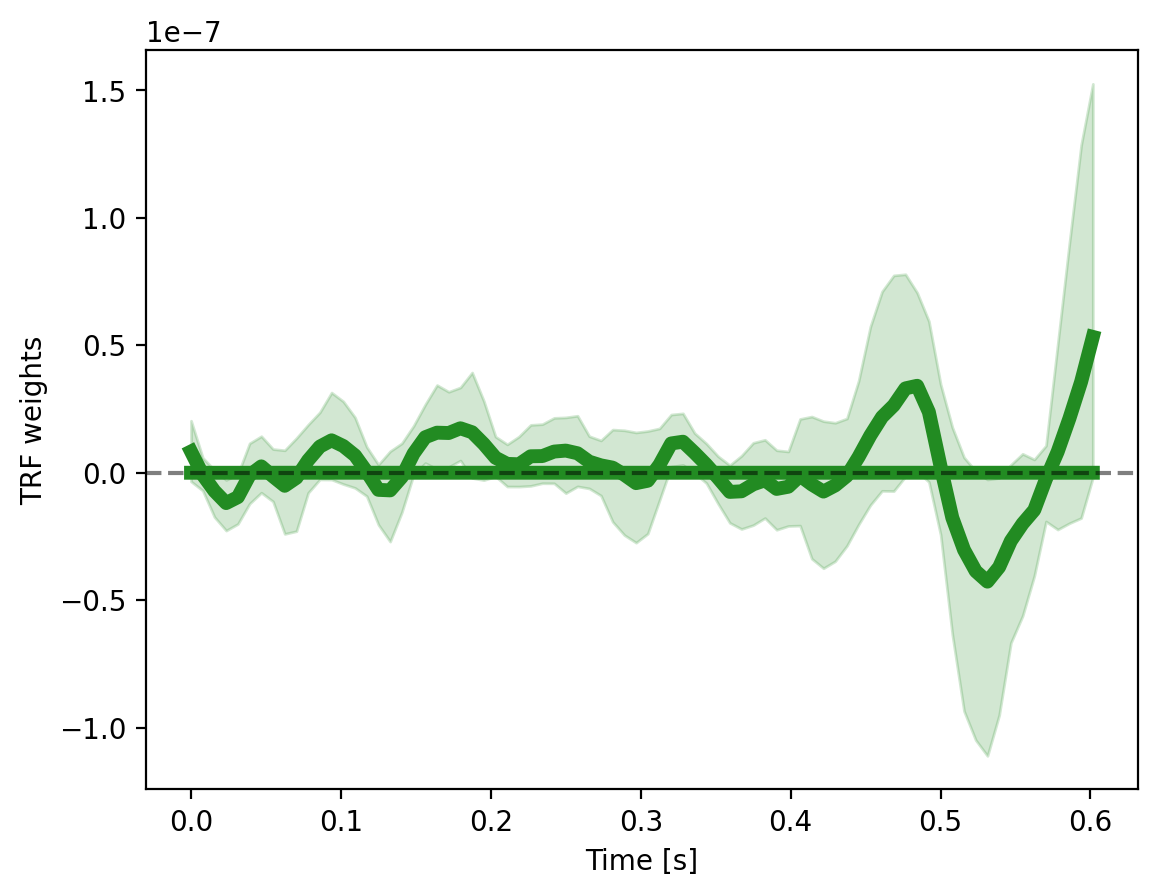

In [ ]:
trf = format_for_plot(rise_trfs, normalize_weights=False)

sns.lineplot(data=trf, y="weights1", x="times", c="forestgreen", lw=5)
sns.lineplot(data=trf, y="weights2", x="times", c="forestgreen", lw=5)
plt.axhline(y=0, ls="--", c="k", alpha=0.5)
plt.xlabel("Time [s]")
plt.ylabel("TRF weights")

## Predict responses using TRFs

In [ ]:
def trf_predict(d1, d2):
    data = pd.merge(d1, d2, on=["id"])
    # use TRFs to predict responses and compute correlation between actual and predicted response
    data[["prediction", "correlation"]] = data.apply(
        lambda x: x.trf.predict(x.stimulus, x.response.flatten()), 
        axis=1, result_type="expand"
    )
    data["prediction"] = data.prediction.transform(lambda x: x[0].flatten())

    return data

In [ ]:
rise_df = trf_predict(rise_data, rise_trfs)
rise_df

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"condition\":\"neutral\",\"stimulus\":[[1091.4240069938423,0.0016628991579636931],[948.7451166821999,0.001056032138876617],[823.648703028701,0.0006751869223080575],[692.6190706418978,0.0003989378164988011],[550.8023439570654,0.0002015329955611378],[426.0983206833161,9.295107884099707e-05],[346.7854691500463,4.2803909309441224e-05],[309.25537438079687,2.479553768353071e-05],[305.0463845325681,1.949146098922938e-05],[325.4176751376728,2.072383176709991e-05],[448.17103398073357,6.300891982391477e-05],[813.3591347019528,0.00033791217720136046],[1183.3531199869922,0.0011621704325079918],[1419.3068023818187,0.0022718023974448442],[1534.4848645657066,0.002809856552630663],[1583.900772345547,0.002762785879895091],[1621.0680455534439,0.0023698252625763416],[1672.2620320407673,0.001985399052500725],[1728.9324361960835,0.0017567743780091405],[1759.707235515707,0.0016460490878671408],[1771.684381497434,0.0016112147131934762],[1743.6784747044635,0.001520214369520545],[1681.5778622459693,0.0013975846813991666],[1595.144408250515,0.0012640987988561392],[1506.3072169277004,0.0011339582270011306],[1393.4479747388277,0.0009247793932445347],[1245.0135587047494,0.000654111965559423],[1041.435626427037,0.0003652491432148963],[829.3313609132384,0.00016836743452586234],[681.5639719645685,8.107850590022281e-05],[650.0953323915892,6.314511847449467e-05],[676.5878211533197,6.547147495439276e-05],[724.845698258378,7.35052817617543e-05],[801.8198980401165,8.858623914420605e-05],[922.3849881307252,0.00011813387391157448],[1083.627296940455,0.00016601783863734454],[1272.6974409422496,0.00023326266091316938],[1458.2761555458492,0.00031219556694850326],[1599.0135584637576,0.0004070875875186175],[1715.4001197324274,0.000548259646166116],[1791.4532727954722,0.0007182031986303627],[1834.808527116374,0.0008794801542535424],[1869.0754529034878,0.0010238307295367122],[1897.4376236682015,0.0011174328392371535],[1926.9044796243347,0.001166229136288166],[1957.6930757188677,0.001235645730048418],[1985.0463799596525,0.0012276382185518742],[2003.1696708874572,0.0012423908337950706],[2005.0656588496654,0.001216694712638855],[1988.4338458351388,0.0010778458090499043],[1940.7477117589224,0.000974995840806514],[1858.3549067221838,0.0008377160411328077],[1746.6820223947575,0.000730831001419574],[1625.3890151033506,0.000641428807284683],[1494.4437371290635,0.0005754164885729551],[1357.6381371538287,0.0004939172067679465],[1223.7721671826362,0.0004114563635084778],[1103.8130018510406,0.00032496056519448757],[1032.9600453815779,0.00025892749545164406],[1029.099824467228,0.00024393128114752471],[1038.8590689720222,0.00022597392671741545],[1028.6739656257687,0.000210539874387905],[1009.0437311438404,0.00022068693942856044],[993.8468807734062,0.00023677616263739765],[982.099326462378,0.0002488794852979481],[955.6132570568155,0.00024206622038036585],[940.0539954594553,0.0002491672639735043],[951.2008740443167,0.00026038684882223606],[978.4707210965621,0.00027633082936517894],[1011.3627026025329,0.0002953308867290616],[1037.8141694429528,0.0003135024744551629],[1061.4284124234052,0.00033069305936805904],[1081.2620597064881,0.0003529414243530482],[1094.7518111616919,0.00036742034717462957],[1081.8730968115133,0.0003665892290882766],[1031.7802311310077,0.0003447366470936686],[968.5357914643164,0.0003385211748536676],[918.8069945573272,0.00033259301562793553]],\"response\":[-4.592087962946794e-06,-4.369749692399889e-06,-3.8284838692622665e-06,-1.4880856740655044e-06,1.3353483474312676e-06,3.1306500280749323e-06,4.51672617340391e-06,4.581507226234343e-06,3.198802963267342e-06,1.6190010518596296e-06,4.584048465715057e-07,-1.1736855242702654e-06,-4.358698994326759e-06,-7.1508081943103995e-06,-7.612814490596357e-06,-6.6219084363496795e-06,-5.961525335969417e-06,-4.386096835931689e-06,-1.7964069987512583e-06,1.803286418552516e-07,7.229223029708696e-07,5.6277443110774016e-08,-1.288371024994602e-06,-2.4550687307078035e-06,

In [ ]:
# test = rise_df.loc[(rise_df.condition=="fall") & (rise_df.feature=="pitch")]
# test = test.loc[:, ["id", "times", "stimulus", "response", "prediction"]]
# test = test.explode(column=["times", "stimulus", "response", "prediction"]).reset_index(drop=True)

# for subj_id in test.id.unique():
#     sub_data = test.loc[test.id==subj_id]

#     fig, axs = plt.subplots(ncols=3, figsize=(12, 4))
#     plt.tight_layout()

#     sns.lineplot(data=sub_data, x="times", y="stimulus", ax=axs[0])
#     axs[0].set_title(f"{subj_id}: [{min(sub_data.stimulus):.2f}, {max(sub_data.stimulus):.2f}]")

#     sns.lineplot(data=sub_data, x="times", y="response", ax=axs[1])
#     axs[1].set_title(f"[{min(sub_data.response):.1e}, {max(sub_data.response):.1e}]")

#     sns.lineplot(data=sub_data, x="times", y="prediction", ax=axs[2])    
#     axs[2].set_title(f"[{min(sub_data.prediction):.1e}, {max(sub_data.prediction):.1e}]")

#     plt.show()

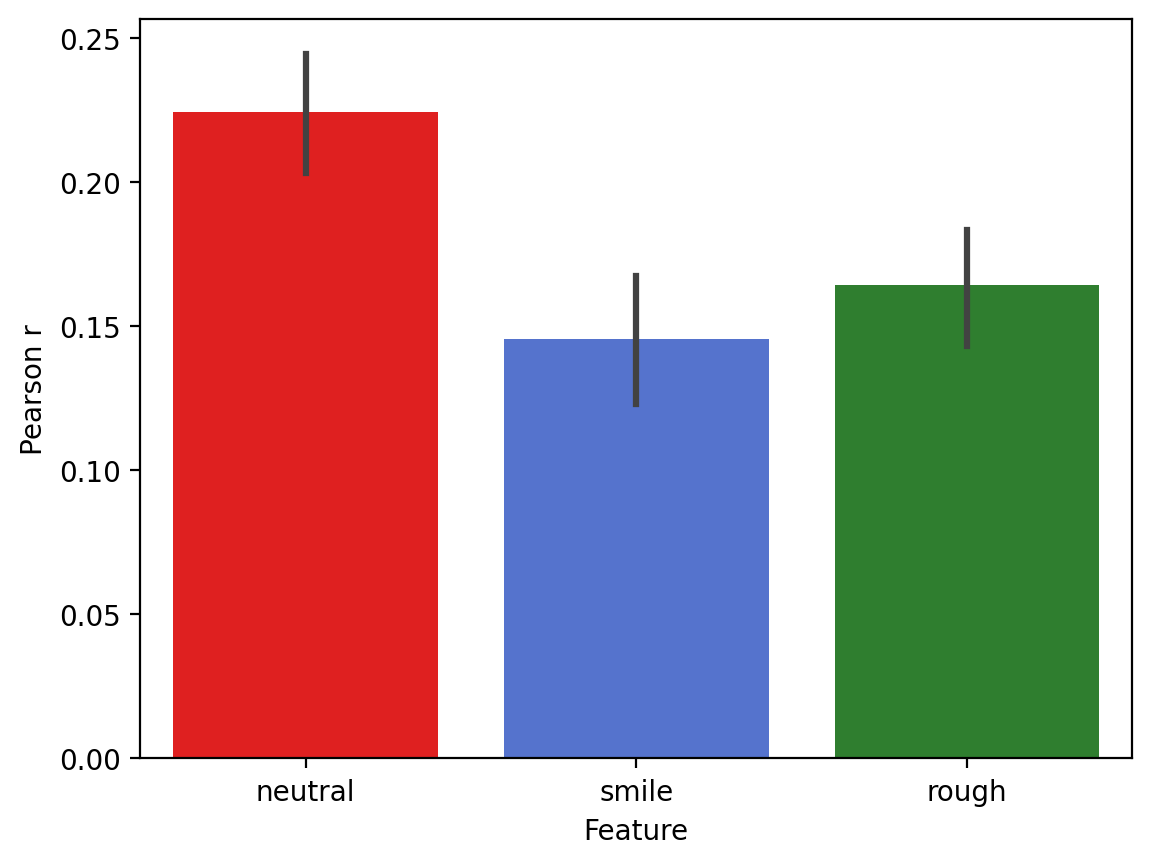

In [ ]:
sns.barplot(
    data=rise_df, x="condition", y="correlation", order=["neutral", "smile", "rough"],
    hue="condition", hue_order=["neutral", "smile", "rough"], palette=["r", "royalblue", "forestgreen"]
)
plt.xlabel("Feature")
plt.ylabel("Pearson r")

## Temporal cluster permutation test

In [ ]:
def cluster_permutation(data, prediction_condition, color):
    data = data.loc[
        data.condition==prediction_condition, 
        ["id", "times", "response", "prediction"]
    ]
    data = data.melt(id_vars=["id", "times"], value_vars=["response", "prediction"])
    ds = make_eelbrain_dataset(data)
    print(ds.summary())

    res_timecoure = eb.testnd.TTestRelated(
        'pz', 'condition', 'response', 'prediction', match='id', data=ds,
        pmin=0.05,
        tstart=0,
        tstop=0.600,
        mintime=0.1
    )
    clusters = res_timecoure.find_clusters(0.05)
    print(clusters)

    p = eb.plot.UTSStat(
        'pz', 'condition', match='id', error="ci", within_subject_error=False, data=ds, run=False,
        ylabel="Pz Amplitude [μV]", colors= {
            ("response"): eb.plot.Style(color="k", linestyle='-', linewidth=4),
            ("prediction"): eb.plot.Style(color=color, linestyle='-', linewidth=4),
        }, legend=False, h=4, w=6,
    )
    # p.set_ylim(-2e-6, 6e-6)
    p.set_clusters(clusters)
    plt.axhline(y=0, ls="--", c="k", alpha=0.5)
    plt.legend(frameon=False)

    return plt.gcf()

In [ ]:
def make_eelbrain_dataset(data):
    rows = []
    for idx, row in data.iterrows():
        subject = eb.Var(int(row.id))
        # Factor needs to be array-like of values
        condition = eb.Factor([row.variable])
        time = eb.UTS(tmin=0, tstep=row.times[1]-row.times[0], nsamples=len(row.times))
        pz_data = eb.NDVar(row.value, dims=(time,))

        case = [subject, condition, pz_data]
        rows.append(case)

    ds = eb.Dataset().from_caselist(names=["id", "condition", "pz"], cases=rows)

    return ds

In [ ]:
tcp_df = rise_df.loc[:, ["id", "condition", "times", "stimulus", "response", "prediction"]]
tcp_df = tcp_df.explode(column=["times", "stimulus", "response", "prediction"]).reset_index(drop=True)
tcp_df = tcp_df.groupby(["id", "condition", "times"]).mean().reset_index()
tcp_df = tcp_df.groupby(["id", "condition"])[["times", "stimulus", "response", "prediction"]].agg(list).reset_index()
# tcp_df["response"] = tcp_df.response.apply(zscore)
# tcp_df["prediction"] = tcp_df.prediction.apply(zscore)
tcp_df

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"id\":\"0004\",\"condition\":\"neutral\",\"times\":[0.0,0.0078125,0.015625,0.0234375,0.03125,0.0390625,0.046875,0.0546875,0.0625,0.0703125,0.078125,0.0859375,0.09375,0.1015625,0.109375,0.1171875,0.125,0.1328125,0.140625,0.1484375,0.15625,0.1640625,0.171875,0.1796875,0.1875,0.1953125,0.203125,0.2109375,0.21875,0.2265625,0.234375,0.2421875,0.25,0.2578125,0.265625,0.2734375,0.28125,0.2890625,0.296875,0.3046875,0.3125,0.3203125,0.328125,0.3359375,0.34375,0.3515625,0.359375,0.3671875,0.375,0.3828125,0.390625,0.3984375,0.40625,0.4140625,0.421875,0.4296875,0.4375,0.4453125,0.453125,0.4609375,0.46875,0.4765625,0.484375,0.4921875,0.5,0.5078125,0.515625,0.5234375,0.53125,0.5390625,0.546875,0.5546875,0.5625,0.5703125,0.578125,0.5859375,0.59375,0.6015625],\"stimulus\":[[1091.42400699384,0.0016628991579636931],[948.7451166821995,0.001056032138876617],[823.648703028702,0.0006751869223080575],[692.6190706418985,0.0003989378164988011],[550.8023439570658,0.0002015329955611378],[426.0983206833156,9.295107884099707e-05],[346.7854691500467,4.2803909309441224e-05],[309.25537438079726,2.479553768353071e-05],[305.04638453256837,1.949146098922938e-05],[325.4176751376727,2.072383176709991e-05],[448.17103398073306,6.300891982391477e-05],[813.3591347019535,0.00033791217720136046],[1183.3531199869908,0.0011621704325079918],[1419.3068023818194,0.0022718023974448442],[1534.4848645657048,0.002809856552630663],[1583.9007723455443,0.002762785879895091],[1621.0680455534452,0.0023698252625763416],[1672.2620320407696,0.001985399052500725],[1728.9324361960857,0.0017567743780091405],[1759.7072355157034,0.0016460490878671408],[1771.6843814974316,0.0016112147131934762],[1743.6784747044621,0.001520214369520545],[1681.5778622459657,0.0013975846813991666],[1595.1444082505177,0.0012640987988561392],[1506.3072169277004,0.0011339582270011306],[1393.4479747388261,0.0009247793932445347],[1245.0135587047507,0.000654111965559423],[1041.4356264270364,0.0003652491432148963],[829.3313609132385,0.00016836743452586234],[681.5639719645692,8.107850590022281e-05],[650.0953323915892,6.314511847449467e-05],[676.5878211533199,6.547147495439276e-05],[724.8456982583791,7.35052817617543e-05],[801.8198980401154,8.858623914420605e-05],[922.3849881307253,0.00011813387391157448],[1083.6272969404538,0.00016601783863734454],[1272.6974409422508,0.00023326266091316938],[1458.276155545846,0.00031219556694850326],[1599.01355846376,0.0004070875875186175],[1715.4001197324258,0.000548259646166116],[1791.453272795476,0.0007182031986303627],[1834.8085271163732,0.0008794801542535424],[1869.075452903489,0.0010238307295367122],[1897.4376236682006,0.0011174328392371535],[1926.904479624335,0.001166229136288166],[1957.69307571887,0.001235645730048418],[1985.0463799596498,0.0012276382185518742],[2003.169670887457,0.0012423908337950706],[2005.0656588496645,0.001216694712638855],[1988.433845835138,0.0010778458090499043],[1940.7477117589183,0.000974995840806514],[1858.3549067221854,0.0008377160411328077],[1746.6820223947575,0.000730831001419574],[1625.3890151033527,0.000641428807284683],[1494.4437371290658,0.0005754164885729551],[1357.6381371538296,0.0004939172067679465],[1223.7721671826341,0.0004114563635084778],[1103.8130018510415,0.00032496056519448757],[1032.960045381579,0.00025892749545164406],[1029.0998244672276,0.00024393128114752471],[1038.8590689720236,0.00022597392671741545],[1028.67396562577,0.000210539874387905],[1009.0437311438421,0.00022068693942856044],[993.846880773404,0.00023677616263739765],[982.0993264623781,0.0002488794852979481],[955.6132570568154,0.00024206622038036585],[940.0539954594566,0.0002491672639735043],[951.2008740443173,0.00026038684882223606],[978.470721096562,0.00027633082936517894],[1011.362702602534,0.0002953308867290616],[1037.8141694429517,0.0003135024744551629],[1061.4284124234057,0.00033069305936805904],[1081.262059706487,0.0003529414243530482],[1094.7518111616941,0.00036742034717462957],[1081.87309681151

Key         Type     Values                             
--------------------------------------------------------
id          Var      4 - 37                             
condition   Factor   response:13, prediction:13         
pz          NDVar    78 time; -6.17299e-06 - 1.17795e-05
--------------------------------------------------------
Dataset: 26 cases
#   id   tstart   tstop   duration   v   p   sig
------------------------------------------------


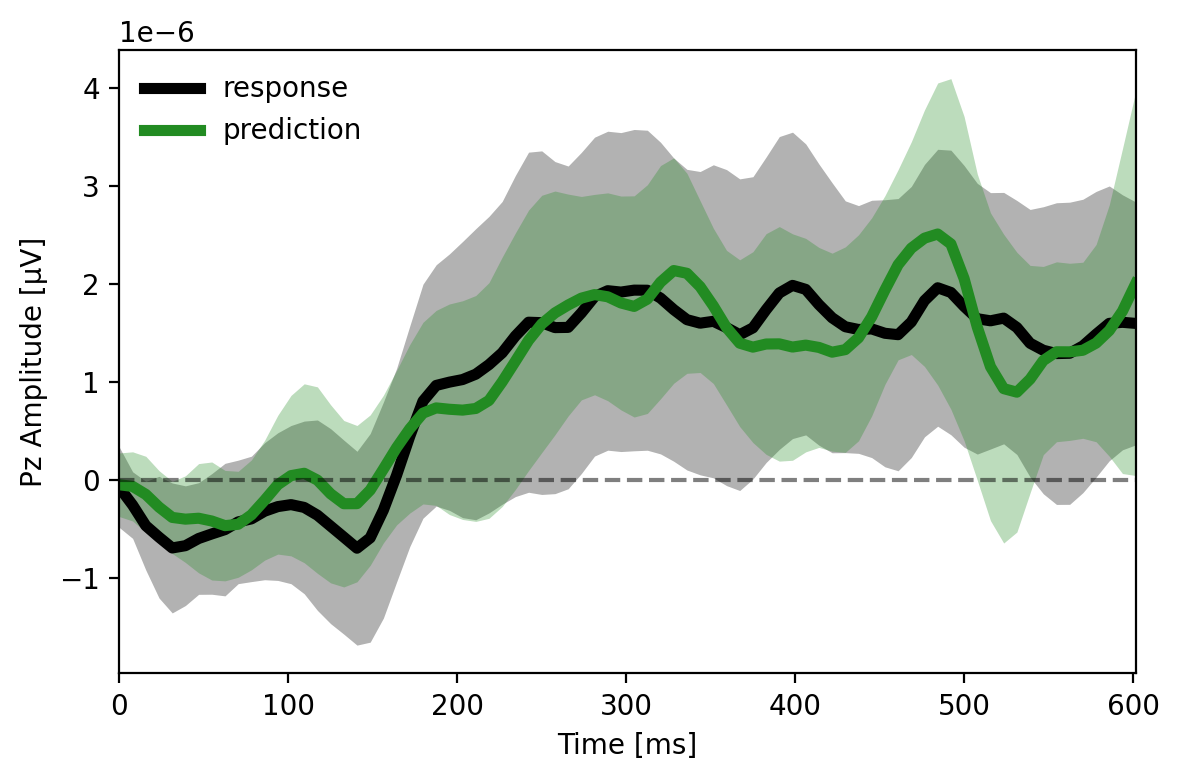

In [ ]:
cluster_permutation(data=tcp_df, prediction_condition="rough", color="forestgreen")

## Statistical tests between TRF fits

In [ ]:
import pingouin as pg

In [ ]:
pd.concat([
    pg.ttest(
        x=rise_df.loc[rise_df.condition=="neutral"].correlation,
        y=rise_df.loc[rise_df.condition=="rise"].correlation,
        paired=True
    ),
    pg.ttest(
        x=rise_df.loc[rise_df.condition=="neutral"].correlation,
        y=rise_df.loc[rise_df.condition=="fall"].correlation,
        paired=True
    ),
    pg.ttest(
        x=rise_df.loc[rise_df.condition=="rise"].correlation,
        y=rise_df.loc[rise_df.condition=="fall"].correlation,
        paired=True
    )
])

<marimo-table data-initial-value='[]' data-label='null' data-data='"[{\"\":\"T-test\",\"T\":5.376980041599107,\"dof\":1039,\"alternative\":\"two-sided\",\"p-val\":9.354015047449954e-08,\"CI95%\":[0.05,0.11],\"cohen-d\":0.22754089908127306,\"BF10\":\"5.226e+04\",\"power\":0.9999999608960245},{\"\":\"T-test\",\"T\":4.135770532795541,\"dof\":1039,\"alternative\":\"two-sided\",\"p-val\":3.823244228979037e-05,\"CI95%\":[0.03,0.09],\"cohen-d\":0.17803583723377345,\"BF10\":\"164.721\",\"power\":0.9999203821981193},{\"\":\"T-test\",\"T\":-1.3010249956858384,\"dof\":1039,\"alternative\":\"two-sided\",\"p-val\":0.19353834543392615,\"CI95%\":[-0.05,0.01],\"cohen-d\":0.05395420759607687,\"BF10\":\"0.081\",\"power\":0.41242061538530295}]"' data-total-rows='3' data-total-columns='8' data-max-columns='50' data-banner-text='""' data-pagination='true' data-page-size='10' data-field-types='[["T",["number","float64"]],["dof",["integer","int64"]],["alternative",["string","object"]],["p-val",["number","float64"]],["CI95%",["string","object"]],["cohen-d",["number","float64"]],["BF10",["string","object"]],["power",["number","float64"]]]' data-show-filters='true' data-show-download='true' data-show-column-summaries='false' data-show-data-types='true' data-show-page-size-selector='false' data-show-column-explorer='true' data-show-chart-builder='true' data-row-headers='[["",["string","object"]]]' data-has-stable-row-id='false' data-lazy='false' data-preload='false'>

In [ ]:
pd.concat([
    pg.ttest(
        x=rise_df.loc[rise_df.condition=="neutral"].correlation,
        y=rise_df.loc[rise_df.condition=="smile"].correlation,
        paired=True
    ),
    pg.ttest(
        x=rise_df.loc[rise_df.condition=="neutral"].correlation,
        y=rise_df.loc[rise_df.condition=="rough"].correlation,
        paired=True
    ),
    pg.ttest(
        x=rise_df.loc[rise_df.condition=="smile"].correlation,
        y=rise_df.loc[rise_df.condition=="rough"].correlation,
        paired=True
    )
])